In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from src.custom_fastkan import FastKAN
import pandas as pd
import torch.nn.functional as F

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalize to [-1, 1]
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)


X_train_full = train_dataset.data.view(-1, 784).float() / 255.0
X_train_full = X_train_full * 2 - 1
y_train_full = train_dataset.targets

X_test = test_dataset.data.view(-1, 784).float() / 255.0
X_test = X_test * 2 - 1
y_test = test_dataset.targets

torch.manual_seed(42)
indices = torch.randperm(len(X_train_full))
val_size = 10000
train_size = len(X_train_full) - val_size

train_indices = indices[:train_size]
val_indices = indices[train_size:]

X_train = X_train_full[train_indices].to(device)
y_train = y_train_full[train_indices].to(device)

X_val = X_train_full[val_indices].to(device)
y_val = y_train_full[val_indices].to(device)

X_test = X_test.to(device)
y_test = y_test.to(device)

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")
print(f"Classes: {len(torch.unique(y_train))}")

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:00<00:00, 21903926.38it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 557507.07it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:00<00:00, 5392701.33it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 2320688.12it/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Train shape: torch.Size([50000, 784]), Val shape: torch.Size([10000, 784]), Test shape: torch.Size([10000, 784])
Classes: 10


In [3]:
model = FastKAN([784, 64, 10], grid_min=-1.2, grid_max=1.2, num_grids=5, use_base_update=False, use_layernorm=False).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

In [4]:
print("Training KAN...")
train_losses = []
val_losses = []
train_accs = []
val_accs = []

batch_size = 256
num_batches = len(X_train) // batch_size

for epoch in range(20): 
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    indices = torch.randperm(len(X_train))
    for i in range(0, len(X_train), batch_size):
        batch_idx = indices[i:i+batch_size]
        X_batch = X_train[batch_idx]
        y_batch = y_train[batch_idx]
        
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        _, predicted = torch.max(pred.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
        
    avg_train_loss = epoch_loss / (len(X_train) / batch_size)
    train_acc = 100 * correct / total
    
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val).item()
        _, val_predicted = torch.max(val_pred.data, 1)
        val_acc = 100 * (val_predicted == y_val).sum().item() / len(y_val)
    
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch}, Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

model.eval()
with torch.no_grad():
    test_pred = model(X_test)
    test_loss = criterion(test_pred, y_test).item()
    _, test_predicted = torch.max(test_pred.data, 1)
    test_acc = 100 * (test_predicted == y_test).sum().item() / len(y_test)
    
    print(f"\nKAN Test Loss: {test_loss:.4f}")
    print(f"KAN Test Accuracy: {test_acc:.2f}%")

Training KAN...
Epoch 0, Train Loss: 1.2789, Train Acc: 67.68%, Val Loss: 0.6662, Val Acc: 85.41%
Epoch 1, Train Loss: 0.4783, Train Acc: 88.76%, Val Loss: 0.4003, Val Acc: 89.52%
Epoch 2, Train Loss: 0.3228, Train Acc: 91.65%, Val Loss: 0.3128, Val Acc: 91.73%
Epoch 3, Train Loss: 0.2580, Train Acc: 93.10%, Val Loss: 0.2904, Val Acc: 92.03%
Epoch 4, Train Loss: 0.2171, Train Acc: 94.29%, Val Loss: 0.2690, Val Acc: 92.11%
Epoch 5, Train Loss: 0.2028, Train Acc: 94.53%, Val Loss: 0.2493, Val Acc: 92.78%
Epoch 6, Train Loss: 0.1640, Train Acc: 95.64%, Val Loss: 0.2493, Val Acc: 92.60%
Epoch 7, Train Loss: 0.1532, Train Acc: 95.85%, Val Loss: 0.2740, Val Acc: 91.77%
Epoch 8, Train Loss: 0.1652, Train Acc: 95.58%, Val Loss: 0.2630, Val Acc: 92.58%
Epoch 9, Train Loss: 0.1523, Train Acc: 95.89%, Val Loss: 0.2433, Val Acc: 92.96%
Epoch 10, Train Loss: 0.1322, Train Acc: 96.50%, Val Loss: 0.2341, Val Acc: 92.88%
Epoch 11, Train Loss: 0.1136, Train Acc: 97.07%, Val Loss: 0.2362, Val Acc: 93.02


Analyzing individual KAN prediction losses...

KAN Loss Statistics:
Mean Loss: 0.221572
Min Loss: 0.000002
Max Loss: 11.308685


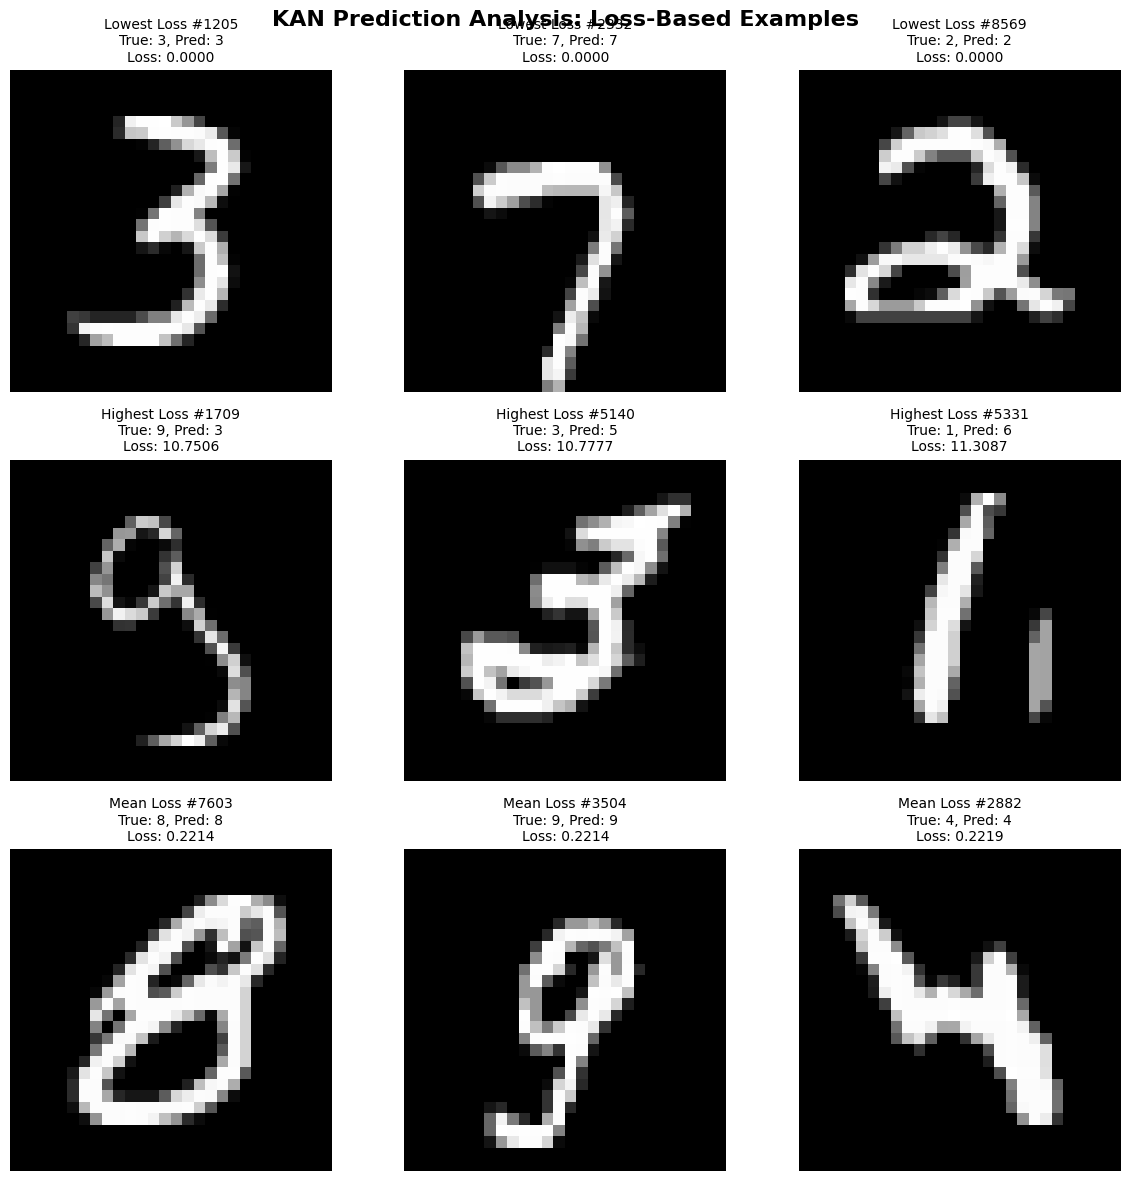

In [5]:
def plot_mnist_prediction(input_img, ground_truth, prediction, probs, example_idx, loss_val, category, ax):
    img = input_img.reshape(28, 28).cpu().numpy()
    img = (img + 1) / 2
    
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{category} #{example_idx}\nTrue: {ground_truth}, Pred: {prediction}\nLoss: {loss_val:.4f}', fontsize=10)
    ax.axis('off')

print("\nAnalyzing individual KAN prediction losses...")
individual_losses = []
predictions = []
probabilities = []

with torch.no_grad():
    logits = model(X_test)
    loss_per_sample = F.cross_entropy(logits, y_test, reduction='none')
    probs = F.softmax(logits, dim=1)
    _, preds = torch.max(logits, 1)
    
    individual_losses = loss_per_sample.cpu().numpy()
    predictions = preds.cpu().numpy()
    probabilities = probs.cpu().numpy()

sorted_indices = np.argsort(individual_losses)

mean_loss = np.mean(individual_losses)
lowest_indices = sorted_indices[:3] 
highest_indices = sorted_indices[-3:]

mean_distances = np.abs(individual_losses - mean_loss)
mean_sorted_indices = np.argsort(mean_distances)
mean_indices = mean_sorted_indices[:3]

print(f"\nKAN Loss Statistics:")
print(f"Mean Loss: {mean_loss:.6f}")
print(f"Min Loss: {individual_losses[lowest_indices[0]]:.6f}")
print(f"Max Loss: {individual_losses[highest_indices[-1]]:.6f}")

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('KAN Prediction Analysis: Loss-Based Examples', fontsize=16, fontweight='bold')

for i, idx in enumerate(lowest_indices):
    plot_mnist_prediction(
        X_test[idx], y_test[idx].item(), predictions[idx], probabilities[idx],
        idx, individual_losses[idx], "Lowest Loss", axes[0, i]
    )
for i, idx in enumerate(highest_indices):
    plot_mnist_prediction(
        X_test[idx], y_test[idx].item(), predictions[idx], probabilities[idx],
        idx, individual_losses[idx], "Highest Loss", axes[1, i]
    )
for i, idx in enumerate(mean_indices):
    plot_mnist_prediction(
        X_test[idx], y_test[idx].item(), predictions[idx], probabilities[idx],
        idx, individual_losses[idx], "Mean Loss", axes[2, i]
    )
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

In [6]:
import torch.nn as nn
torch.manual_seed(42)

class MLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=[16], output_dim=10):
        super(MLP, self).__init__()
        layers = []
        curr_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(curr_dim, h_dim))
            layers.append(nn.ReLU())
            curr_dim = h_dim
        layers.append(nn.Linear(curr_dim, output_dim))
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

mlp_model = MLP(input_dim=784, hidden_dims=[16], output_dim=10).to(device)
mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001)

print("Training MLP...")
mlp_train_losses = []
mlp_val_losses = []
mlp_train_accs = []
mlp_val_accs = []

for epoch in range(15):
    mlp_model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    indices = torch.randperm(len(X_train))
    for i in range(0, len(X_train), batch_size):
        batch_idx = indices[i:i+batch_size]
        X_batch = X_train[batch_idx]
        y_batch = y_train[batch_idx]
        
        mlp_optimizer.zero_grad()
        pred = mlp_model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        mlp_optimizer.step()
        
        epoch_loss += loss.item()
        _, predicted = torch.max(pred.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
        
    avg_train_loss = epoch_loss / (len(X_train) / batch_size)
    train_acc = 100 * correct / total
    
    mlp_model.eval()
    with torch.no_grad():
        val_pred = mlp_model(X_val)
        val_loss = criterion(val_pred, y_val).item()
        _, val_predicted = torch.max(val_pred.data, 1)
        val_acc = 100 * (val_predicted == y_val).sum().item() / len(y_val)
    
    mlp_train_losses.append(avg_train_loss)
    mlp_val_losses.append(val_loss)
    mlp_train_accs.append(train_acc)
    mlp_val_accs.append(val_acc)
    
    print(f"Epoch {epoch}, Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

mlp_model.eval()
with torch.no_grad():
    mlp_test_pred = mlp_model(X_test)
    mlp_test_loss = criterion(mlp_test_pred, y_test).item()
    _, mlp_test_predicted = torch.max(mlp_test_pred.data, 1)
    mlp_test_acc = 100 * (mlp_test_predicted == y_test).sum().item() / len(y_test)
    
    print(f"\nMLP Test Loss: {mlp_test_loss:.4f}")
    print(f"MLP Test Accuracy: {mlp_test_acc:.2f}%")

Training MLP...
Epoch 0, Train Loss: 0.9293, Train Acc: 73.56%, Val Loss: 0.5043, Val Acc: 85.72%
Epoch 1, Train Loss: 0.4258, Train Acc: 87.90%, Val Loss: 0.3909, Val Acc: 88.54%
Epoch 2, Train Loss: 0.3520, Train Acc: 89.85%, Val Loss: 0.3436, Val Acc: 90.01%
Epoch 3, Train Loss: 0.3256, Train Acc: 90.60%, Val Loss: 0.3257, Val Acc: 90.70%
Epoch 4, Train Loss: 0.3086, Train Acc: 91.22%, Val Loss: 0.3191, Val Acc: 91.08%
Epoch 5, Train Loss: 0.2971, Train Acc: 91.43%, Val Loss: 0.3203, Val Acc: 90.80%
Epoch 6, Train Loss: 0.2914, Train Acc: 91.65%, Val Loss: 0.3076, Val Acc: 91.23%
Epoch 7, Train Loss: 0.2843, Train Acc: 91.92%, Val Loss: 0.3011, Val Acc: 91.39%
Epoch 8, Train Loss: 0.2776, Train Acc: 92.04%, Val Loss: 0.3083, Val Acc: 91.40%
Epoch 9, Train Loss: 0.2759, Train Acc: 92.16%, Val Loss: 0.2930, Val Acc: 91.81%
Epoch 10, Train Loss: 0.2689, Train Acc: 92.42%, Val Loss: 0.2946, Val Acc: 91.60%
Epoch 11, Train Loss: 0.2643, Train Acc: 92.52%, Val Loss: 0.2958, Val Acc: 91.76

In [7]:
from sklearn.metrics import r2_score, mean_squared_error

def calculate_metrics(model, X, y):
    model.eval()
    with torch.no_grad():
        logits = model(X)
        probs = F.softmax(logits, dim=1)
        
        # One-hot encode targets
        y_onehot = F.one_hot(y, num_classes=10).float()
        
        # Move to CPU for sklearn
        probs_np = probs.cpu().numpy()
        y_onehot_np = y_onehot.cpu().numpy()
        
        # Calculate MSE
        mse = mean_squared_error(y_onehot_np, probs_np)
        
        # Calculate R2 (average over all output dimensions)
        r2 = r2_score(y_onehot_np, probs_np)
        
        return mse, r2

kan_mse, kan_r2 = calculate_metrics(model, X_test, y_test)
mlp_mse, mlp_r2 = calculate_metrics(mlp_model, X_test, y_test)

print(f"KAN Test MSE: {kan_mse:.6f}, R2: {kan_r2:.6f}")
print(f"MLP Test MSE: {mlp_mse:.6f}, R2: {mlp_r2:.6f}")

KAN Test MSE: 0.009967, R2: 0.887960
MLP Test MSE: 0.011358, R2: 0.872409



Analyzing individual MLP prediction losses...

MLP Loss Statistics:
Mean Loss: 0.260452
Min Loss: 0.000000
Max Loss: 15.532155


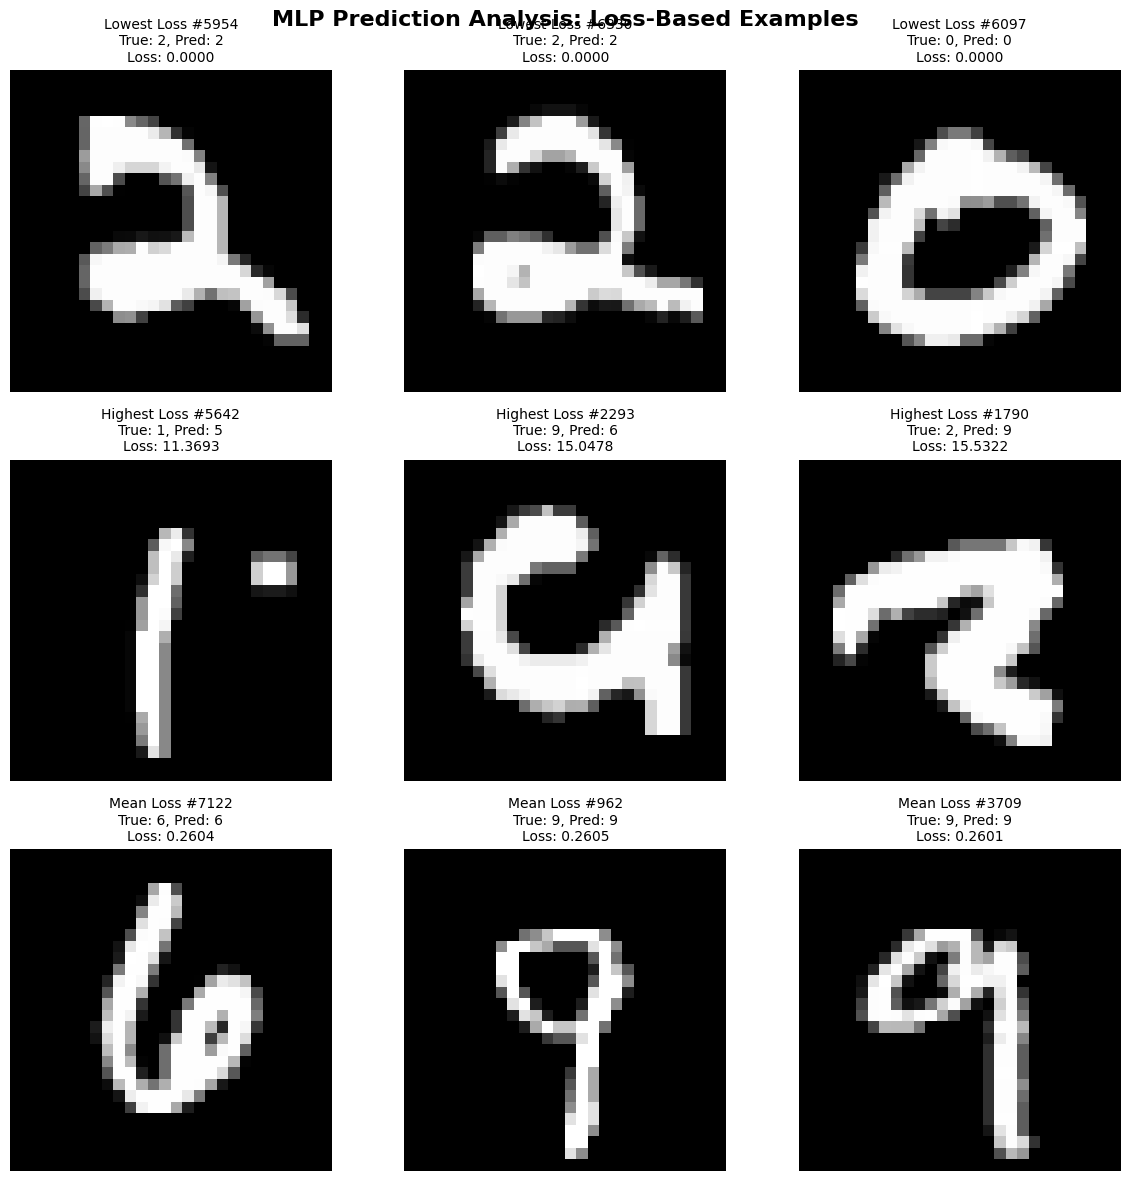

In [8]:
print(f"\nAnalyzing individual MLP prediction losses...")
individual_losses = []
predictions = []
probabilities = []

mlp_model.eval()
with torch.no_grad():
    logits = mlp_model(X_test)
    loss_per_sample = F.cross_entropy(logits, y_test, reduction='none')
    probs = F.softmax(logits, dim=1)
    _, preds = torch.max(logits, 1)
    
    individual_losses = loss_per_sample.cpu().numpy()
    predictions = preds.cpu().numpy()
    probabilities = probs.cpu().numpy()

sorted_indices = np.argsort(individual_losses)

mean_loss = np.mean(individual_losses)
lowest_indices = sorted_indices[:3] 
highest_indices = sorted_indices[-3:]

mean_distances = np.abs(individual_losses - mean_loss)
mean_sorted_indices = np.argsort(mean_distances)
mean_indices = mean_sorted_indices[:3]

print(f"\nMLP Loss Statistics:")
print(f"Mean Loss: {mean_loss:.6f}")
print(f"Min Loss: {individual_losses[lowest_indices[0]]:.6f}")
print(f"Max Loss: {individual_losses[highest_indices[-1]]:.6f}")

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('MLP Prediction Analysis: Loss-Based Examples', fontsize=16, fontweight='bold')

for i, idx in enumerate(lowest_indices):
    plot_mnist_prediction(
        X_test[idx], y_test[idx].item(), predictions[idx], probabilities[idx],
        idx, individual_losses[idx], "Lowest Loss", axes[0, i]
    )
for i, idx in enumerate(highest_indices):
    plot_mnist_prediction(
        X_test[idx], y_test[idx].item(), predictions[idx], probabilities[idx],
        idx, individual_losses[idx], "Highest Loss", axes[1, i]
    )
for i, idx in enumerate(mean_indices):
    plot_mnist_prediction(
        X_test[idx], y_test[idx].item(), predictions[idx], probabilities[idx],
        idx, individual_losses[idx], "Mean Loss", axes[2, i]
    )
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()


Analyzing individual MLP prediction losses...

MLP Loss Statistics:
Mean Loss: 0.260452
Min Loss: 0.000000
Max Loss: 15.532155


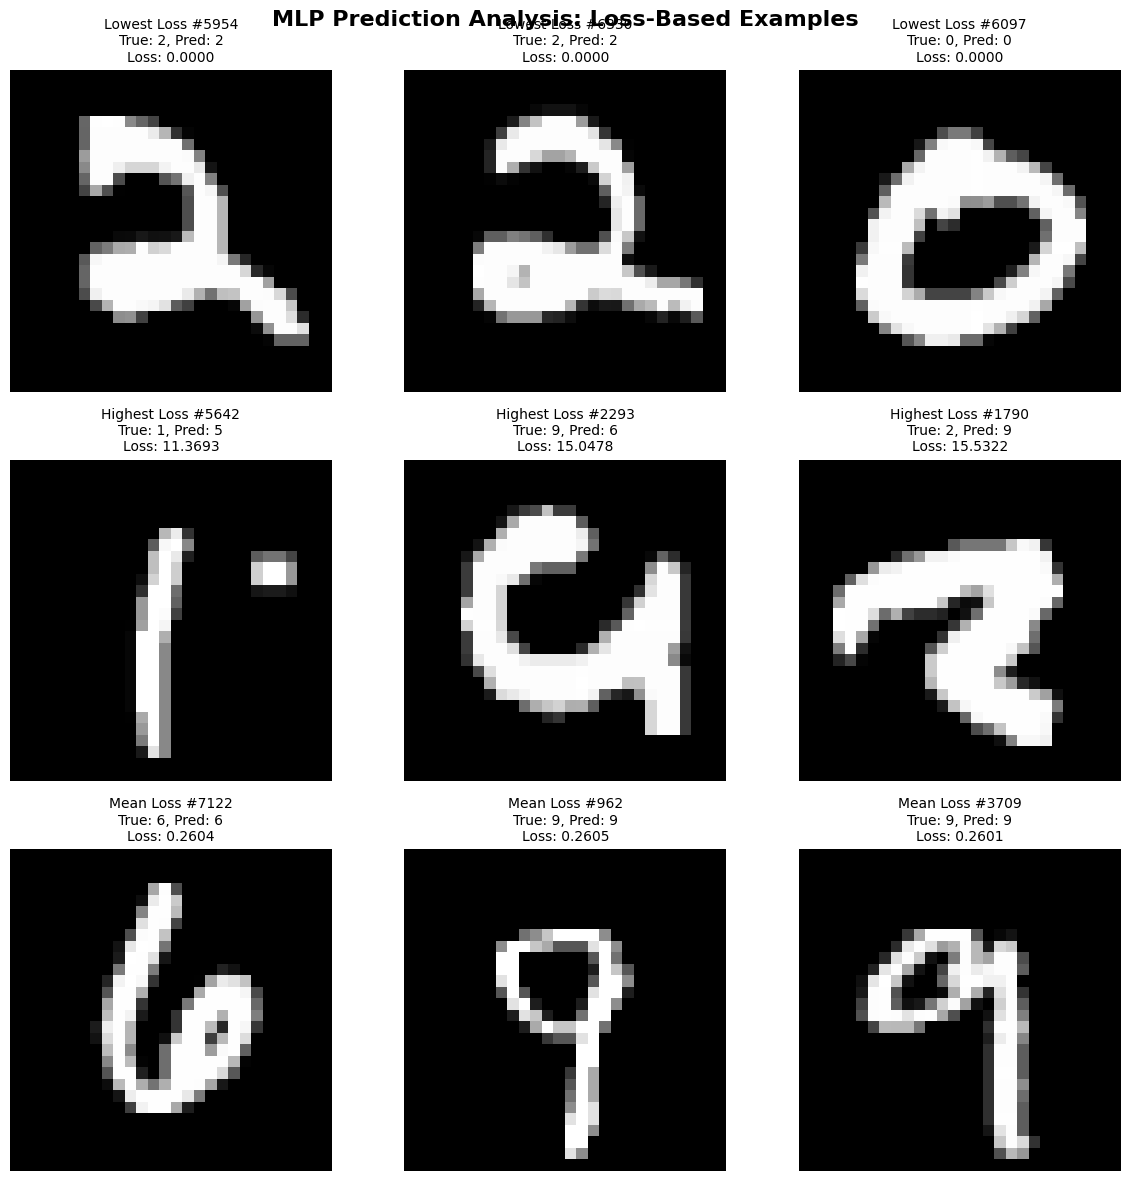

In [9]:
print("\nAnalyzing individual MLP prediction losses...")
mlp_individual_losses = []
mlp_predictions = []
mlp_probabilities = []

with torch.no_grad():
    logits = mlp_model(X_test)
    loss_per_sample = F.cross_entropy(logits, y_test, reduction='none')
    probs = F.softmax(logits, dim=1)
    _, preds = torch.max(logits, 1)
    
    mlp_individual_losses = loss_per_sample.cpu().numpy()
    mlp_predictions = preds.cpu().numpy()
    mlp_probabilities = probs.cpu().numpy()

mlp_sorted_indices = np.argsort(mlp_individual_losses)

mlp_mean_loss = np.mean(mlp_individual_losses)
mlp_lowest_indices = mlp_sorted_indices[:3] 
mlp_highest_indices = mlp_sorted_indices[-3:]

mlp_mean_distances = np.abs(mlp_individual_losses - mlp_mean_loss)
mlp_mean_sorted_indices = np.argsort(mlp_mean_distances)
mlp_mean_indices = mlp_mean_sorted_indices[:3]

print(f"\nMLP Loss Statistics:")
print(f"Mean Loss: {mlp_mean_loss:.6f}")
print(f"Min Loss: {mlp_individual_losses[mlp_lowest_indices[0]]:.6f}")
print(f"Max Loss: {mlp_individual_losses[mlp_highest_indices[-1]]:.6f}")

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('MLP Prediction Analysis: Loss-Based Examples', fontsize=16, fontweight='bold')

for i, idx in enumerate(mlp_lowest_indices):
    plot_mnist_prediction(
        X_test[idx], y_test[idx].item(), mlp_predictions[idx], mlp_probabilities[idx],
        idx, mlp_individual_losses[idx], "Lowest Loss", axes[0, i]
    )
for i, idx in enumerate(mlp_highest_indices):
    plot_mnist_prediction(
        X_test[idx], y_test[idx].item(), mlp_predictions[idx], mlp_probabilities[idx],
        idx, mlp_individual_losses[idx], "Highest Loss", axes[1, i]
    )
for i, idx in enumerate(mlp_mean_indices):
    plot_mnist_prediction(
        X_test[idx], y_test[idx].item(), mlp_predictions[idx], mlp_probabilities[idx],
        idx, mlp_individual_losses[idx], "Mean Loss", axes[2, i]
    )
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

In [10]:
table_data = []
categories = [("Lowest", lowest_indices), ("Highest", highest_indices), ("Mean", mean_indices)]

for label, indices in categories:
    for idx in indices:
        table_data.append({
            "Category": label,
            "Index": idx,
            "True Label": y_test[idx].item(),
            "Predicted Label": predictions[idx].item(),
            "Confidence": f"{probabilities[idx][predictions[idx]]:.4f}",
            "Loss": individual_losses[idx]
        })

df_kan_analysis = pd.DataFrame(table_data)
df_kan_analysis

,Category,Index,True Label,Predicted Label,Confidence,Loss
0,Lowest,5954,2,2,1.0000,4.768370e-07
1,Lowest,6330,2,2,1.0000,1.549720e-06
2,Lowest,6097,0,0,1.0000,1.549720e-06
3,Highest,5642,1,5,0.9094,1.136925e+01
4,Highest,2293,9,6,0.7488,1.504781e+01
5,Highest,1790,2,9,0.8641,1.553216e+01
6,Mean,7122,6,6,0.7707,2.604221e-01
7,Mean,962,9,9,0.7706,2.605338e-01
8,Mean,3709,9,9,0.7710,2.601077e-01


In [11]:
table_data_mlp = []
categories = [("Lowest", mlp_lowest_indices), ("Highest", mlp_highest_indices), ("Mean", mlp_mean_indices)]

for label, indices in categories:
    for idx in indices:
        table_data_mlp.append({
            "Category": label,
            "Index": idx,
            "True Label": y_test[idx].item(),
            "Predicted Label": mlp_predictions[idx].item(),
            "Confidence": f"{mlp_probabilities[idx][mlp_predictions[idx]]:.4f}",
            "Loss": mlp_individual_losses[idx]
        })

df_mlp_analysis = pd.DataFrame(table_data_mlp)
df_mlp_analysis

,Category,Index,True Label,Predicted Label,Confidence,Loss
0,Lowest,5954,2,2,1.0000,4.768370e-07
1,Lowest,6330,2,2,1.0000,1.549720e-06
2,Lowest,6097,0,0,1.0000,1.549720e-06
3,Highest,5642,1,5,0.9094,1.136925e+01
4,Highest,2293,9,6,0.7488,1.504781e+01
5,Highest,1790,2,9,0.8641,1.553216e+01
6,Mean,7122,6,6,0.7707,2.604221e-01
7,Mean,962,9,9,0.7706,2.605338e-01
8,Mean,3709,9,9,0.7710,2.601077e-01


In [12]:
mlp_save_path = "model_pkls/mnist_mlp_model.pkl"
torch.save({
    'model_state_dict': mlp_model.state_dict(),
    'config': {
        'input_dim': 784,
        'hidden_dims': [256, 256],
        'output_dim': 10
    }
}, mlp_save_path)
print(f"MLP Model saved to {mlp_save_path}")

MLP Model saved to model_pkls/mnist_mlp_model.pkl


In [13]:
kan_save_path = "model_pkls/mnist_kan_model.pkl"
torch.save({
    'model_state_dict': model.state_dict(),
    'config': {
        'layers_hidden': [784, 64, 10],
        'grid_min': -1.2,
        'grid_max': 1.2,
        'num_grids': 5,
        'use_base_update': False,
        'use_layernorm': False,
    }
}, kan_save_path)
print(f"KAN Model saved to {kan_save_path}")

KAN Model saved to model_pkls/mnist_kan_model.pkl
